# Rubin Early Data Preview 2 (EDP2) — LSDB tutorial

In this tutorial, we will:
- Open the Rubin Data Preview 2 HATS catalog in LSDB
- Select specific columns for analysis
- Plot the catalog
- Select a region of the sky with a cone search
- Restrict the catalog by querying column values
- Map a function across the catalog
- Compute the catalog
- Write the catalog to disk
- Read the catalog from disk
- Cross-match the catalog with another catalog

If you just want a minimal code example, see the [**Starter Code**](https://docs.lsdb.io/en/latest/tutorials/pre_executed/rubin_dp2_starter.html) notebook.

Make sure you choose the **latest Weekly release** when you run this notebook on the RSP. This will give you the latest software versions with bug fixes and performance improvements.

## Setup

In [1]:
import lsdb

import astropy.units as u
from astropy.coordinates import SkyCoord
from upath import UPath
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "axes.titlesize": 16,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
    }
)

In [2]:
import logging

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)

In [3]:
# Setup
from dask.distributed import Client

client = Client(n_workers=4, memory_limit="4GiB", threads_per_worker=1)

We can keep an eye on the Dask dashboard to monitor our compute usage.

In [4]:
print(f"Dask dashboard: {client.dashboard_link}")

Dask dashboard: http://127.0.0.1:14179/status


### Further reading
[Tutorial: Setting up a Dask Client](https://docs.lsdb.io/en/latest/tutorials/dask_client.html)  
[Tutorial: Dask cluster configuration tips](https://docs.lsdb.io/en/latest/tutorials/dask-cluster-tips.html)

## Open catalog

First, let's open the Rubin DP2 catalog and plot its coverage.

In [5]:
# Open DP2 catalog
# Path on RSP
base_path = UPath("/rubin/lsdb_data")
cat = lsdb.open_catalog(base_path / "object_collection")

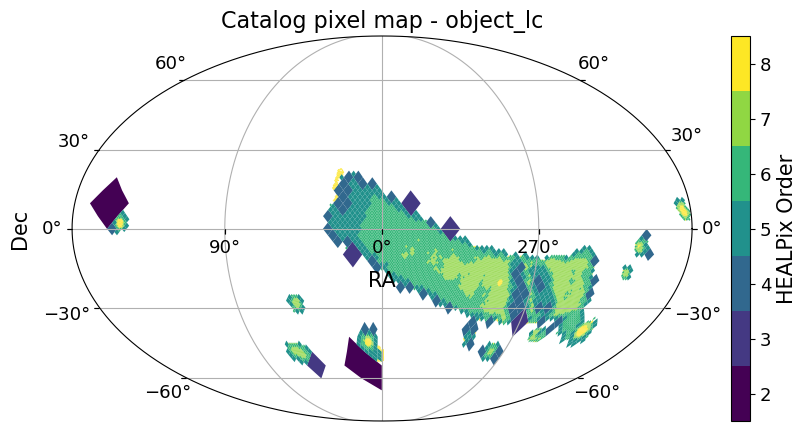

In [6]:
cat.plot_pixels();

### Further reading
[Tutorial: The Catalog Object](https://docs.lsdb.io/en/latest/tutorials/catalog_object.html)  
[Documentation: `Catalog`](https://docs.lsdb.io/en/latest/reference/catalog.html)

## Lazy evaluation

The catalog has been loaded *lazily*: no data has been read, only the catalog schema.

First we will filter the catalog down to only the data we need. Later, we will compute the catalog to download the data.

### Futher reading

Tutorial: **Why Lazy Evaluation?**  
[Tutorial: Lazy Operations in LSDB](https://docs.lsdb.io/en/latest/tutorials/lazy_operations.html)

## Choose columns

The full object catalog has more than a thousand columns. To keep things fast, LSDB opens only a curated **default subset** of columns unless you ask for more. For a description of the catalogs and their columns, see [About the EDP2 HATS Catalogs](https://docs.lsdb.io/en/latest/tutorials/rubin_dp2_release.html).

Let's take a look at the default columns that were loaded:

In [7]:
cat.columns

Index(['coord_dec', 'coord_decErr', 'coord_ra', 'coord_raErr', 'g_psfFlux',
       'g_psfFluxErr', 'g_psfMag', 'g_psfMagErr', 'i_psfFlux', 'i_psfFluxErr',
       'i_psfMag', 'i_psfMagErr', 'objectId', 'patch', 'r_psfFlux',
       'r_psfFluxErr', 'r_psfMag', 'r_psfMagErr', 'refBand', 'shape_flag',
       'shape_xx', 'shape_xy', 'shape_yy', 'tract', 'u_psfFlux',
       'u_psfFluxErr', 'u_psfMag', 'u_psfMagErr', 'y_psfFlux', 'y_psfFluxErr',
       'y_psfMag', 'y_psfMagErr', 'z_psfFlux', 'z_psfFluxErr', 'z_psfMag',
       'z_psfMagErr', 'objectForcedSource'],
      dtype='object')

We can request specific columns with `lsdb.open_catalog(..., columns=[...])`, or load every column with `columns="all"`. Note that `coord_ra` and `coord_dec` are always included.

In [8]:
cat = lsdb.open_catalog(base_path / "object_collection", columns=["g_psfMag", "r_psfMag"])
cat

,g_psfMag,r_psfMag,coord_ra,coord_dec
npartitions=8840,,,,
"Order: 8, Pixel: 10240",float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...,...
"Order: 5, Pixel: 12283",...,...,...,...
"Order: 5, Pixel: 12284",...,...,...,...


Choosing only these columns cut down the size of the catalog from 873.2 GB to 25.0 GB — less than 3%.

### Further reading
[Tutorial: column filtering](https://github.com/astronomy-commons/lsdb/blob/main/docs/tutorials/column_filtering.ipynb)  
[Documentation: `lsdb.open_catalog()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.open_catalog.html)


## Per-partition statistics

Before loading any data, we can inspect what each partition contains directly from the parquet **footer metadata** with `Catalog.per_partition_statistics()`. For every column in every partition, HATS records the minimum and maximum value, the null count, and the row count. Reading these is essentially instantaneous — no data is downloaded and no Dask computation runs.

This is useful for cheaply sanity-checking a catalog: seeing value ranges before you filter, estimating how many rows sit in each pixel, or spotting which partitions actually have data for a given band.

Here we restrict the report to our two magnitude columns and the first few partitions using `include_columns` and `include_pixels`:

In [9]:
cat.per_partition_statistics(
    include_columns=["g_psfMag", "r_psfMag"],
    include_stats=["min_value", "max_value", "null_count", "row_count"],
    include_pixels=cat.get_healpix_pixels()[:5],
)

,g_psfMag: min_value,g_psfMag: max_value,g_psfMag: null_count,g_psfMag: row_count,r_psfMag: min_value,r_psfMag: max_value,r_psfMag: null_count,r_psfMag: row_count
"Order: 8, Pixel: 10240",NaN,NaN,1638,1638,15.023277,30.679514,21,1638
"Order: 8, Pixel: 10241",NaN,NaN,1012,1012,15.046271,30.720203,20,1012
"Order: 8, Pixel: 10242",NaN,NaN,201,201,17.168407,25.641367,5,201
"Order: 8, Pixel: 10243",NaN,NaN,863,863,14.899392,29.638235,10,863
"Order: 8, Pixel: 10244",NaN,NaN,219,219,18.576580,28.114025,12,219


Notice that for these partitions `g_psfMag` has `null_count` equal to `row_count` (they contain no g-band detections at all) while `r_psfMag` is populated. `per_partition_statistics` surfaces that from metadata alone, without reading a single row.

A few useful options:
- `include_columns` / `exclude_columns`: limit which columns are reported.
- `include_stats`: choose any of `min_value`, `max_value`, `null_count`, `row_count`.
- `include_pixels`: choose any number of pixels to include in the report.
- `per_row_group=True`: return one row per parquet row-group instead of one per partition.
- `multi_index=True`: return a `(pixel, column)` MultiIndex instead of flattened `"column: stat"` columns.

> **Note:** these statistics come from the on-disk metadata, so they describe the full stored partitions and do **not** reflect lazy filters (such as `query` or `cone_search`) applied to the catalog. Calling `per_partition_statistics` on a filtered catalog will warn you of exactly that.

### Further reading
[Documentation: `lsdb.Catalog.per_partition_statistics()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.per_partition_statistics.html)

## Plot skymaps

We can see the spatial density of the catalog with a skymap:

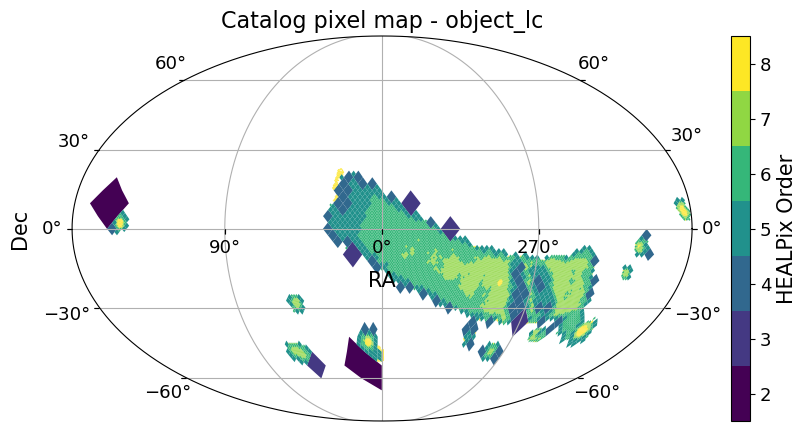

In [10]:
cat.plot_pixels();

We can also zoom in to a region in the sky. Let's focus near (ra=10, dec=-5).

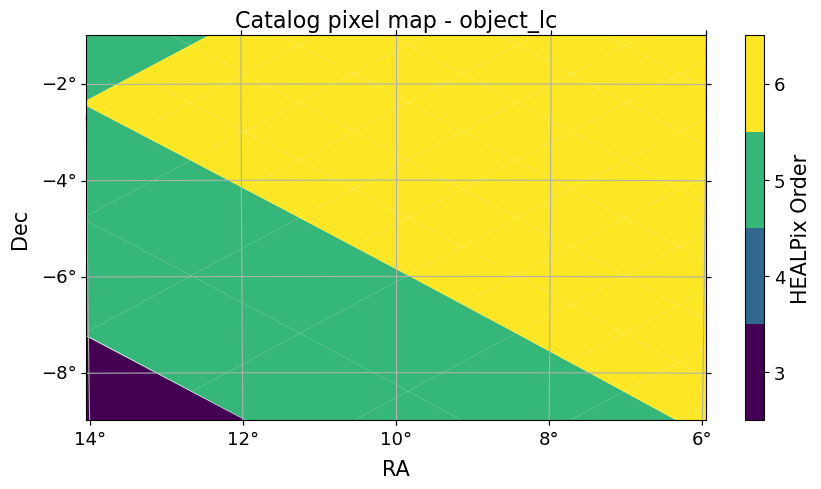

In [11]:
import astropy.units as u

fov = (8 * u.deg, 8 * u.deg)
center = SkyCoord(10 * u.deg, -5 * u.deg)
fig, ax = cat.plot_pixels(projection="AIT", fov=fov, center=center);

We can visualize the angular density in the same region:

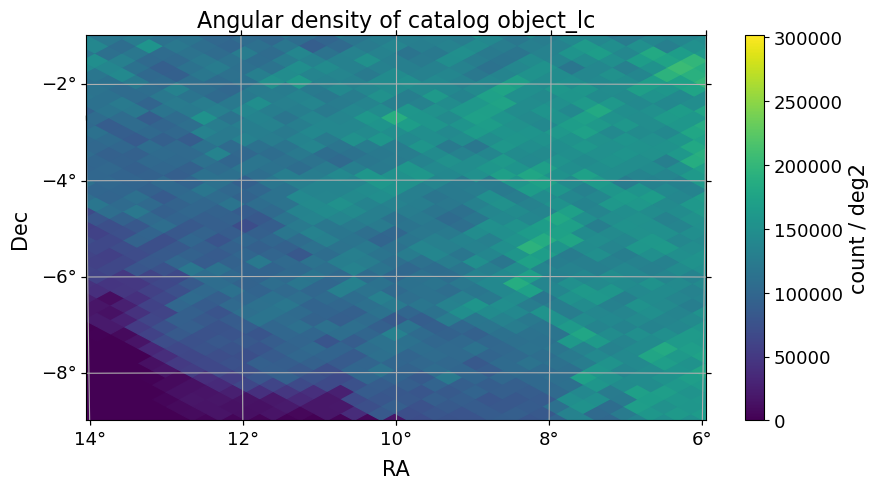

In [12]:
import hats

hats.inspection.plot_density(cat.hc_structure, ec="face", projection="AIT", fov=fov, center=center);

### Further reading

[Tutorial: Plotting Results](https://docs.lsdb.io/en/latest/tutorials/pre_executed/plotting.html)  
[Documentation: `lsdb.Catalog.plot_pixels()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.plot_pixels.html)  
[Documentation: `hats.inspection`](https://hats.readthedocs.io/en/stable/autoapi/hats/inspection/index.html#hats.inspection.plot_density)

## Spatial filtering

Now let's restrict the catalog to the region where we zoomed in.

In [13]:
# Spatial filtering
cat = cat.cone_search(ra=10.0, dec=-5.0, radius_arcsec=2 * 3600)

In [14]:
cat

,g_psfMag,r_psfMag,coord_ra,coord_dec
npartitions=19,,,,
"Order: 5, Pixel: 4482",float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...,...
"Order: 6, Pixel: 17971",...,...,...,...
"Order: 6, Pixel: 17976",...,...,...,...


The filtered catalog is significantly smaller: 

Catalog | Size
-------- | ------
Full DP2 | 1.5 TB
Selected columns | 25.2 GB
Selected columns and cone search | 54.1 MB

And it takes up only the selected region in the sky:

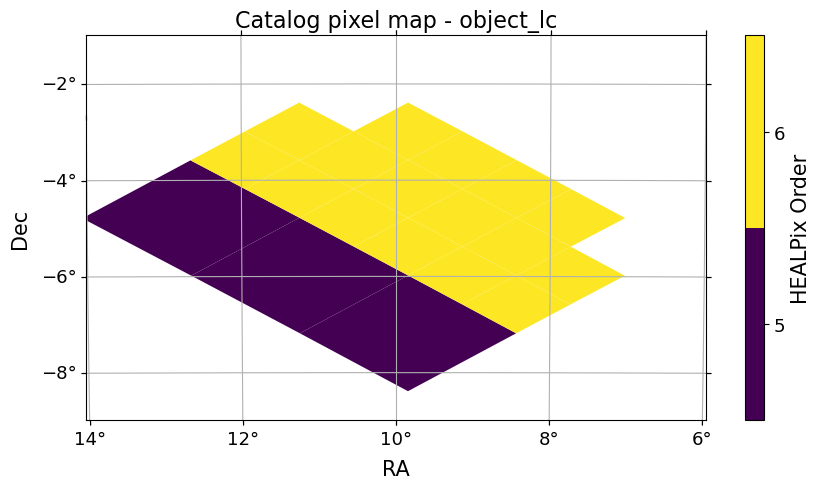

In [15]:
cat.plot_pixels(projection="AIT", fov=fov, center=center);

### Further reading:

[Tutorial: Region Selection](https://docs.lsdb.io/en/latest/tutorials/region_selection.html)  
[Documentation: `lsdb.Catalog.cone_search()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.cone_search.html#lsdb.catalog.Catalog.cone_search)

## Query

We can further filter objects using a query based on the column values.

The query syntax is the same as for [`pandas.DataFrame.query()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html), except that local variables cannot be used.

In [16]:
# Query to filter rows
cat = cat.query("g_psfMag < 28.0 and r_psfMag < 28.0")

Unlike spatial filtering, querying does not change the predicted size of the catalog. In reality, the catalog's size will decrease once we compute it.

In [17]:
cat

,g_psfMag,r_psfMag,coord_ra,coord_dec
npartitions=19,,,,
"Order: 5, Pixel: 4482",float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...,...
"Order: 6, Pixel: 17971",...,...,...,...
"Order: 6, Pixel: 17976",...,...,...,...


### Further reading

[Tutorial: Row Filtering](https://docs.lsdb.io/en/latest/tutorials/row_filtering.html)  
[Documentation: `lsdb.Catalog.query()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.query.html#lsdb.catalog.Catalog.query)

## Mapping a function

We can map a function across all partitions (pixels) in the catalog using `lsdb.Catalog.map_partitions()`. From generating summary statistics per partition, to efficiently calculating transformations in parallel, this ability has many uses.

The mapping function takes in a dataframe that represents a partition—one row per object. It must return a dataframe. Some common usage patterns are:

- Add one or more columns to the dataframe and return it (e.g. calculate some attributes for each object, given the existing attributes). Rows still represent objects, and the number of rows remains the same.
- Return a subset of rows from the dataframe. Rows still represent objects, but the number of rows is less than the original partition.
- Return a dataframe of custom summary statistics for this partition (e.g. median value for each column). Rows no longer represent objects.

In [18]:
# Map a function
def g_minus_r_mapper(df):
    df["g_minus_r_mag"] = df["g_psfMag"] - df["r_psfMag"]
    return df


cat = cat.map_partitions(g_minus_r_mapper)

### Further reading

[Tutorial: `map_partitions`](https://docs.lsdb.io/en/latest/tutorials/pre_executed/map_partitions.html)  
[Documentation: `lsdb.Catalog.map_partitions()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.map_partitions.html)

## Computing a catalog

All operations up to this point have been lazy, and have not downloaded data. To retrieve the data, we must **compute** the catalog.

First, we can use `lsdb.Catalog.head()` to retrieve only a few rows. This lets us make sure that everything looks right before executing a larger-scale computation of the whole catalog.

In [19]:
cat.head(5)

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

,g_psfMag,r_psfMag,coord_ra,coord_dec,g_minus_r_mag
_healpix_29,,,,,
1261770054783963537,23.567427,27.750866,9.387727,-6.903804,-4.183439
1261770060486994182,25.459435,25.13032,9.386266,-6.903903,0.329115
1261770060491471999,23.589426,24.084002,9.386552,-6.903749,-0.494576
1261770060628372753,23.302301,25.299643,9.385689,-6.903057,-1.997341
1261770062830375321,25.315023,25.074331,9.383639,-6.900418,0.240692


We should now be able to see the task being executed in the Dask client. Check the Dask dashboard link near the beginning of this notebook and verify that you see activity.

Any time we compute the catalog, the result is a `nested_pandas.NestedFrame`, which is a kind of `pandas.DataFrame`.

In [20]:
df = cat.head(5)
print(type(df))
import pandas as pd

print(isinstance(df, pd.DataFrame))

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

<class 'nested_pandas.nestedframe.core.NestedFrame'>
True


Everything looks right, so let's compute the whole catalog.

In [21]:
# Compute catalog and write to disk
cat.write_catalog("dp2_example_cat", overwrite=True)

Writing Catalog:   0%|          | 0/19 [00:00<?, ?it/s]

Writing Margin Cache:   0%|          | 0/24 [00:00<?, ?it/s]

In [22]:
# Compute catalog to dataframe
df = cat.compute()

Computing Catalog:   0%|          | 0/19 [00:00<?, ?it/s]

In [23]:
df

,g_psfMag,r_psfMag,coord_ra,coord_dec,g_minus_r_mag
_healpix_29,,,,,
1261770054783963537,23.567427,27.750866,9.387727,-6.903804,-4.183439
1261770060486994182,25.459435,25.13032,9.386266,-6.903903,0.329115
...,...,...,...,...,...
1264957488779219710,23.485807,23.111719,9.642696,-3.406365,0.374088
1264957490399993435,23.47562,22.966101,9.636538,-3.40503,0.50952


In [24]:
# Read catalog from disk
cat = lsdb.open_catalog("dp2_example_cat")

### Further reading

[Documentation: `lsdb.Catalog.compute()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.compute.html)  
[Documentation: `lsdb.Catalog.write_catalog()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.write_catalog.html#lsdb.catalog.Catalog.write_catalog)  
[Documentation: `lsdb.open_catalog()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.open_catalog.html#lsdb.open_catalog)

## Crossmatching

We can combine two catalogs by [cross-matching](https://www.aanda.org/articles/aa/full_html/2017/11/aa30965-17/aa30965-17.html).

As an example, we'll cross-match the Rubin catalog with the [Dark Energy Survey (DES) catalog](https://data.lsdb.io/DES/DES_DR2_(US-East%2C_S3)).

In [25]:
des_cat = lsdb.open_catalog("s3://stpubdata/mast/public/des/hats/des_dr2/", columns=["MAG_AUTO_G"])
des_cat

,MAG_AUTO_G,RA,DEC
npartitions=1582,,,
"Order: 4, Pixel: 0",double[pyarrow],double[pyarrow],double[pyarrow]
...,...,...,...
"Order: 6, Pixel: 47556",...,...,...
"Order: 1, Pixel: 47",...,...,...


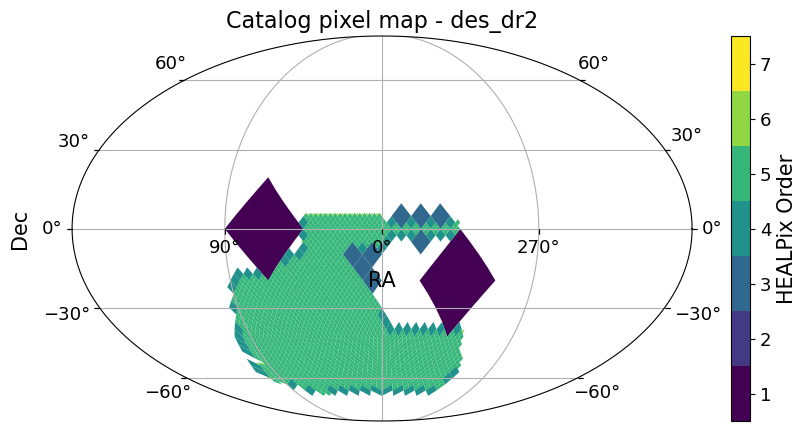

In [26]:
des_cat.plot_pixels();

In [27]:
# Crossmatch Rubin catalog with DES catalog
x_cat = cat.crossmatch(des_cat, suffix_method="overlapping_columns")

In [28]:
x_cat.head()

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

,g_psfMag,r_psfMag,coord_ra,coord_dec,g_minus_r_mag,MAG_AUTO_G,RA,DEC,_dist_arcsec
_healpix_29,,,,,,,,,
1261772975348269355,22.824999,21.217491,9.354591,-6.763164,1.607508,22.549606,9.354593,-6.763168,0.016437
1261772979210506070,23.712337,22.337854,9.343584,-6.76523,1.374483,22.570774,9.343664,-6.765238,0.288975
1261772981394880982,25.01685,23.876198,9.35136,-6.762464,1.140652,24.032064,9.351434,-6.76249,0.281369
1261772981413236414,22.785107,21.315828,9.350297,-6.763012,1.469278,22.043205,9.350302,-6.763015,0.022969
1261772981529417225,23.926285,22.162642,9.350745,-6.761828,1.763643,23.699547,9.350747,-6.761827,0.007049


Let's check that the cross-matched catalog covers the correct sky region. The cross-matched catalog should only contain the region where our filtered Rubin catalog overlaps the DES catalog.

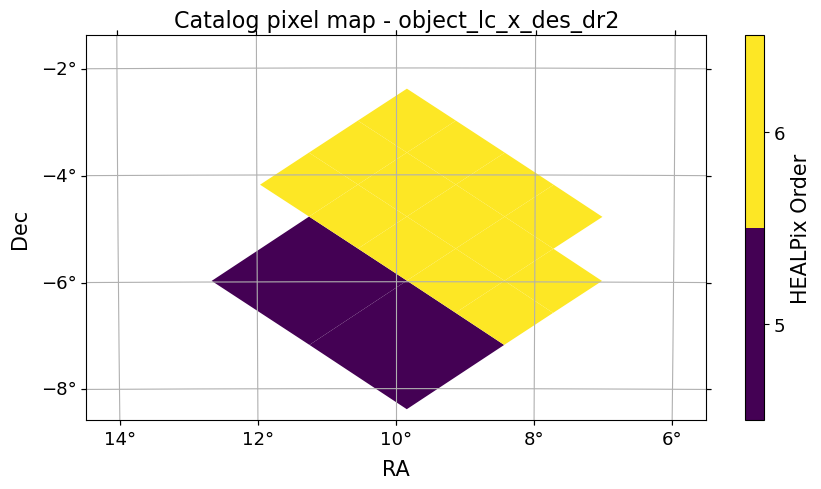

In [29]:
x_cat.plot_pixels(fov=fov, center=center);

In [30]:
x_df = x_cat.compute()

Computing Catalog:   0%|          | 0/16 [00:00<?, ?it/s]

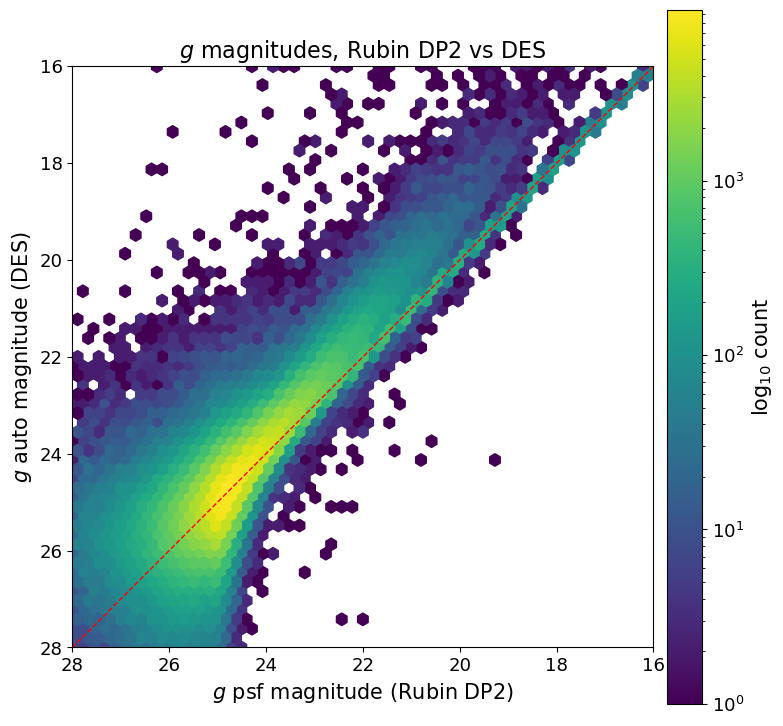

In [31]:
mag_lo, mag_hi = 16.0, 28.0

fig, ax = plt.subplots(figsize=(8, 7.5))
hb = ax.hexbin(
    x_df["g_psfMag"],
    x_df["MAG_AUTO_G"],
    gridsize=55,
    bins="log",
    extent=(mag_lo, mag_hi, mag_lo, mag_hi),
    mincnt=1,
    cmap="viridis",
)
ax.plot([mag_lo, mag_hi], [mag_lo, mag_hi], "r--", lw=1)
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("log$_{10}$ count")

ax.set_xlim(mag_hi, mag_lo)
ax.set_ylim(mag_hi, mag_lo)
ax.set_aspect("equal")
ax.set_xlabel("$g$ psf magnitude (Rubin DP2)")
ax.set_ylabel("$g$ auto magnitude (DES)")
ax.set_title("$g$ magnitudes, Rubin DP2 vs DES")

fig.tight_layout()
plt.show()

### Further reading

[Tutorial: Astrometric epoch propagation](https://docs.lsdb.io/en/latest/tutorials/pre_executed/dp1-gaia-epoch-prop.html)  
[Documentation: `lsdb.Catalog.crossmatch()`](https://docs.lsdb.io/en/latest/reference/api/lsdb.catalog.Catalog.crossmatch.html#lsdb.catalog.Catalog.crossmatch)


## Close Dask client

In [32]:
client.close()